In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
uf = pd.read_csv("A:\\AIML_DEV_FOLDER\\Dataset_self\\diabetes.csv")

In [6]:
uf.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df=uf[['Pregnancies','Glucose','BloodPressure',	'SkinThickness'	,'Insulin',	'BMI','DiabetesPedigreeFunction','Age',	'Outcome'
]]

# i am only picking up the numbercial  id 


In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# drop missing value 

In [19]:
df.dropna()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


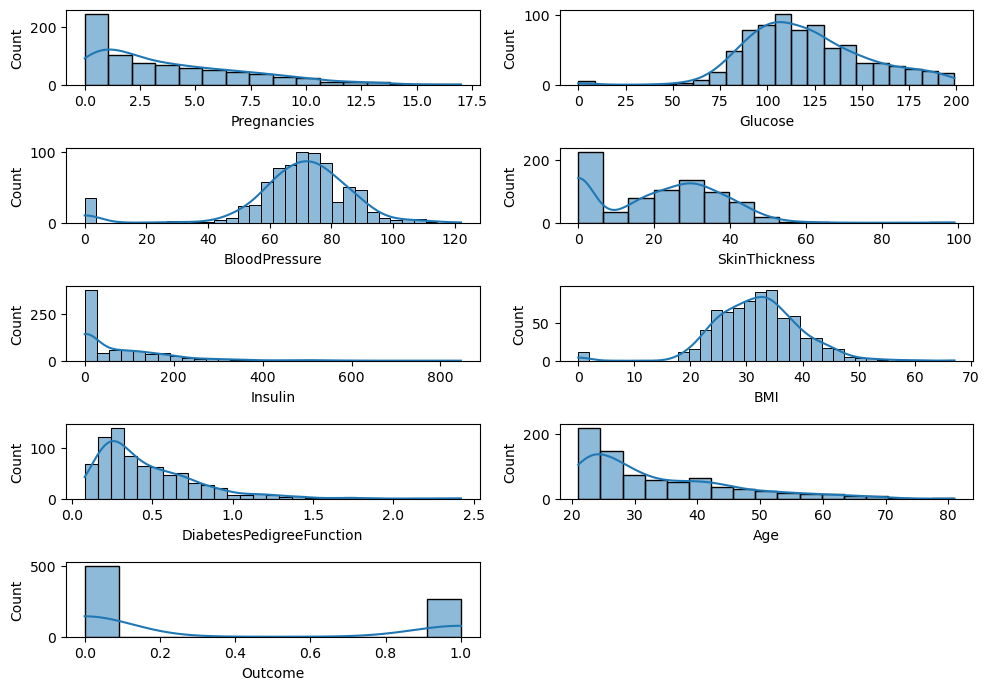

In [9]:
col = ['Pregnancies','Glucose','BloodPressure',	'SkinThickness'	,'Insulin',	'BMI','DiabetesPedigreeFunction','Age',	'Outcome'
]
plt.figure(figsize=(10,7))
for i, col in enumerate(col,1 ):
    plt.subplot(5,2,i)
    sns.histplot(df[col],kde=True)
plt.tight_layout()
plt.show()

# data review 
 *  we will not inclye the last one due to reason 
 

In [10]:
df=df[['Pregnancies','Glucose','BloodPressure',	'SkinThickness'	,'Insulin',	'BMI','DiabetesPedigreeFunction','Age',]]

In [ ]:
df['Pregnancies'].describe()

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

3 while pr

<Axes: xlabel='Pregnancies'>

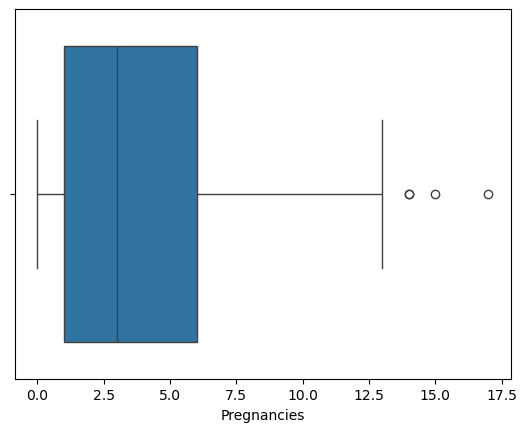

In [14]:
sns.boxplot(x=df['Pregnancies'])

From above image we can see that there are some outlier in the right side 

# As per rule we will calculate the percentile 

In [ ]:
percentile25 = df["Pregnancies"].quantile(0.025)

percentile75 = df["Pregnancies"].quantile(0.75)
print(percentile25, percentile75)

0.0 6.0


 * Now our data is set 
 as we high and low 

# iqr = Q3 - Q1

In [21]:
iqr = percentile75-percentile25
iqr

np.float64(6.0)

## finding upper and lower limit 


In [26]:
upperlimt = percentile75 + 1.5*iqr
lowerlimt = 0
print(upperlimt, lowerlimt)

15.0 0


# Find the outlier 

In [28]:
df[df['Pregnancies'] > upperlimt]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
159,17,163,72,41,114,40.9,0.817,47


In [29]:
df[df['Pregnancies'] < lowerlimt]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


In [30]:
new_trim= df[df['Pregnancies']<upperlimt] # will remove it 17 pregnancies 

# look this diffrence 


In [32]:
print(new_trim.shape,df.shape)


(766, 8) (768, 8)


<Axes: xlabel='Pregnancies'>

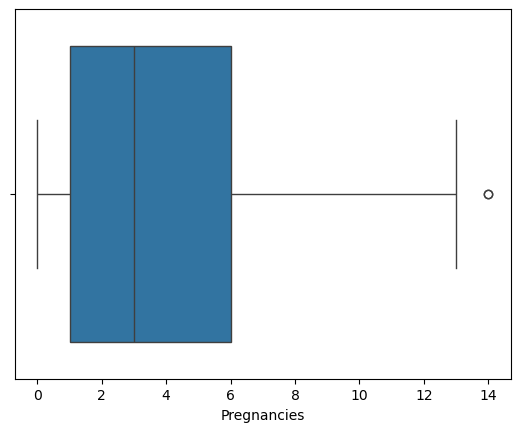

In [34]:
sns.boxplot(x = new_trim["Pregnancies"])

<Axes: xlabel='Pregnancies'>

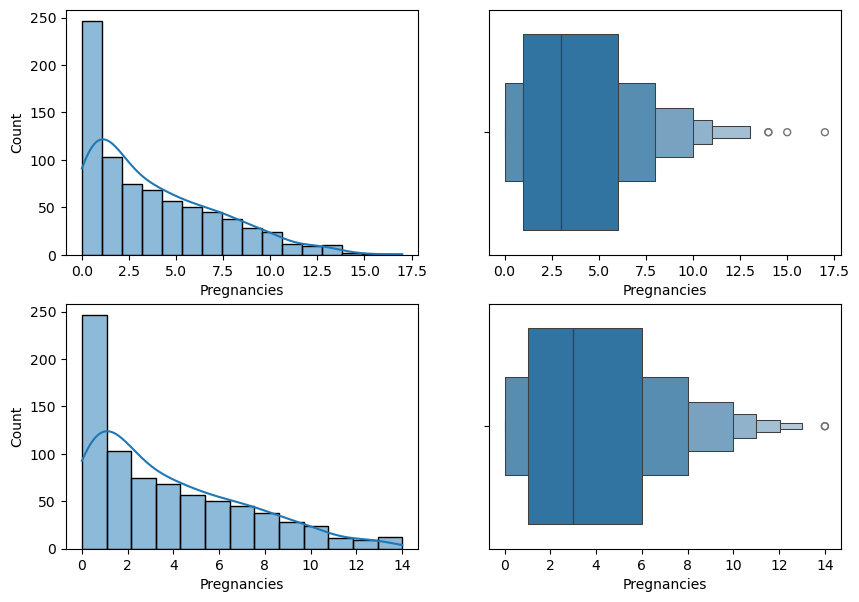

In [36]:
plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
sns.histplot(df["Pregnancies"],kde=True)

plt.subplot(2,2,2)
sns.boxenplot(x=df['Pregnancies'])

plt.subplot(2,2,3)
sns.histplot(new_trim["Pregnancies"],kde=True)

plt.subplot(2,2,4)
sns.boxenplot(x=new_trim['Pregnancies'])


# Capping 

In [40]:
new_df_cap = df.copy()
new_df_cap["Pregnancies"] = np.where(new_df_cap["Pregnancies"]>upperlimt, upperlimt,  

np.where(new_df_cap["Pregnancies"]<lowerlimt, lowerlimt,
new_df_cap["Pregnancies"]         
)
)

<Axes: xlabel='Pregnancies'>

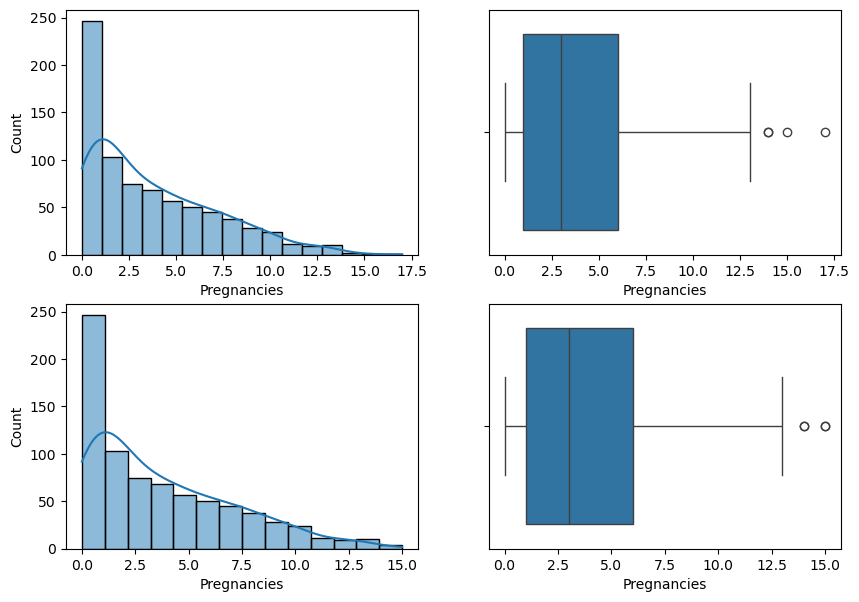

In [45]:
plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
sns.histplot(df['Pregnancies'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(x = df['Pregnancies'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap["Pregnancies"],kde=True)

plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['Pregnancies'])